# Big Data in Behavioural Psychology
## Marco Rosato - University of Milano Bicocca

# Installation & Libraries

In [ ]:
!pip install networkx scikit-learn xgboost shap

In [ ]:
import pickle
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

import seaborn as sns
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
import networkx as nx

import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.utils import resample

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Dataset Load

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Big Data & Psychology /data.csv', sep='\t')

In [ ]:
df

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,4,28,3890,4,25,2122,2,16,1944,4,...,1,1,1,12,1,10,2,1,2,NaN
1,4,2,8118,1,36,2890,2,35,4777,3,...,2,1,2,7,0,70,2,1,4,NaN
2,3,7,5784,1,33,4373,4,41,3242,1,...,2,1,1,4,3,60,1,1,3,NaN
3,2,23,5081,3,11,6837,2,37,5521,1,...,2,1,2,4,5,70,2,1,5,biology
4,2,36,3215,2,13,7731,3,5,4156,4,...,2,2,3,10,1,10,2,1,4,Psychology
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39770,2,31,3287,1,5,2216,3,29,3895,2,...,2,1,1,2,4,60,2,1,2,NaN
39771,3,14,4792,4,41,2604,3,15,2668,4,...,1,1,1,10,0,10,2,1,4,Mathematic
39772,2,1,25147,1,4,4555,2,14,3388,1,...,2,1,1,7,1,30,1,2,3,Computer Science
39773,3,36,4286,1,34,2736,2,10,5968,2,...,2,1,1,6,1,60,1,1,2,History


In [ ]:
df.describe()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,age,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize
count,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,39775.000000,3.977500e+04,39775.000000,...,39775.000000,39775.000000,39775.000000,39775.00000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000,39775.000000
mean,2.619485,21.555977,6.970591e+03,2.172269,21.248070,5.332376e+03,2.226097,21.583004,7.426446e+03,1.950170,...,23.612168,1.274519,1.200025,1.13516,7.555852,1.642992,31.312885,1.705795,1.159547,3.510270
std,1.032117,12.133621,8.670513e+04,1.111563,12.125288,2.651361e+04,1.038526,12.115637,1.587024e+05,1.042218,...,21.581722,0.446277,0.400024,0.40030,3.554395,1.351362,25.871272,0.473388,0.445882,2.141518
min,1.000000,1.000000,1.800000e+02,1.000000,1.000000,1.760000e+02,1.000000,1.000000,-1.081400e+04,1.000000,...,13.000000,1.000000,1.000000,0.00000,0.000000,0.000000,10.000000,0.000000,0.000000,0.000000
25%,2.000000,11.000000,2.664000e+03,1.000000,11.000000,2.477000e+03,1.000000,11.000000,2.857000e+03,1.000000,...,18.000000,1.000000,1.000000,1.00000,4.000000,1.000000,10.000000,1.000000,1.000000,2.000000
50%,3.000000,22.000000,3.609000e+03,2.000000,21.000000,3.511000e+03,2.000000,22.000000,3.898000e+03,2.000000,...,21.000000,1.000000,1.000000,1.00000,10.000000,1.000000,10.000000,2.000000,1.000000,3.000000
75%,4.000000,32.000000,5.358000e+03,3.000000,32.000000,5.216000e+03,3.000000,32.000000,5.766000e+03,3.000000,...,25.000000,2.000000,1.000000,1.00000,10.000000,2.000000,60.000000,2.000000,1.000000,4.000000
max,4.000000,42.000000,1.210228e+07,4.000000,42.000000,2.161057e+06,4.000000,42.000000,2.858269e+07,4.000000,...,1998.000000,2.000000,2.000000,3.00000,12.000000,5.000000,70.000000,2.000000,3.000000,133.000000


In [ ]:
df.isnull()

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,screensize,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39770,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
39771,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
39772,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
39773,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# Data Cleaning, Processing & Analysis

In [ ]:
# Clinical literature identifies these 14 items as the depression subscale
dep_items = ['Q3A', 'Q5A', 'Q10A', 'Q13A', 'Q16A', 'Q17A', 'Q21A', 'Q24A', 'Q26A', 'Q31A', 'Q34A', 'Q37A', 'Q38A', 'Q42A']

# Original responses are 1-4; subtract 1 to get the official 0-3 clinical score
df['Depression_Score'] = df[dep_items].subtract(1).sum(axis=1)

In [ ]:
df

,Q1A,Q1I,Q1E,Q2A,Q2I,Q2E,Q3A,Q3I,Q3E,Q4A,...,uniquenetworklocation,hand,religion,orientation,race,voted,married,familysize,major,Depression_Score
0,4,28,3890,4,25,2122,2,16,1944,4,...,1,1,12,1,10,2,1,2,NaN,27
1,4,2,8118,1,36,2890,2,35,4777,3,...,1,2,7,0,70,2,1,4,NaN,24
2,3,7,5784,1,33,4373,4,41,3242,1,...,1,1,4,3,60,1,1,3,NaN,39
3,2,23,5081,3,11,6837,2,37,5521,1,...,1,2,4,5,70,2,1,5,biology,16
4,2,36,3215,2,13,7731,3,5,4156,4,...,2,3,10,1,10,2,1,4,Psychology,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39770,2,31,3287,1,5,2216,3,29,3895,2,...,1,1,2,4,60,2,1,2,NaN,36
39771,3,14,4792,4,41,2604,3,15,2668,4,...,1,1,10,0,10,2,1,4,Mathematic,38
39772,2,1,25147,1,4,4555,2,14,3388,1,...,1,1,7,1,30,1,2,3,Computer Science,4
39773,3,36,4286,1,34,2736,2,10,5968,2,...,1,1,6,1,60,1,1,2,History,16


In [ ]:
# Data cleaning

# Remove people who claim to know words that do not exist
fakers = df[(df['VCL6'] == 1) | (df['VCL9'] == 1) | (df['VCL12'] == 1)].index

# Remove answered 42 questions in less than 1 minute
speedrunners = df[df['testelapse'] < 60].index

# Remove impossible ages
invalid_age = df[(df['age'] < 13) | (df['age'] > 99)].index

print(f"Fakers (fake words): {len(fakers)}")
print(f"Speedrunners (< 60s): {len(speedrunners)}")
print(f"Invalid age: {len(invalid_age)}")

df = df.drop(index=fakers.union(speedrunners).union(invalid_age), errors='ignore')
print(f"Dataset size after row cleaning: {len(df)}")

Fakers (fake words): 5192
Speedrunners (< 60s): 120
Invalid age: 7
Dataset size after row cleaning: 34511


In [ ]:
# Reaction time analysis

e_cols = [f'Q{i}E' for i in range(1, 43)]

# Global outlier counts
total_answers = df[e_cols].size
too_fast = (df[e_cols] < 500).sum().sum()
too_slow = (df[e_cols] > 300000).sum().sum()

print(f"GLOBAL REACTION TIME ANALYSIS")
print(f"Total answers: {total_answers:,}")
print(f"Physically impossible (< 0.5s): {too_fast:,} ({too_fast/total_answers:.2%})")
print(f"AFK / Interruptions (> 5min): {too_slow:,} ({too_slow/total_answers:.2%})")

# Distribution of outliers per user
outliers_per_user = ((df[e_cols] < 500) | (df[e_cols] > 300000)).sum(axis=1)
print("\nOutliers per user")
print(outliers_per_user.value_counts().sort_index().head(10))

GLOBAL REACTION TIME ANALYSIS
Total answers: 1,449,462
Physically impossible (< 0.5s): 4,096 (0.28%)
AFK / Interruptions (> 5min): 1,095 (0.08%)

Outliers per user
0    32642
1     1433
2      172
3       54
4       18
5       11
6       10
7       13
8       11
9        9
Name: count, dtype: int64


In [ ]:
# Remove users with any invalid reaction time
MIN_TIME = 500      # 0.5 seconds
MAX_TIME = 300000   # 5 minutes

too_fast = (df[e_cols] < MIN_TIME).any(axis=1)
too_slow = (df[e_cols] > MAX_TIME).any(axis=1)
negative_mask = (df[e_cols] <= 0).any(axis=1)

rows_to_drop = df[too_fast | too_slow | negative_mask].index
print(f"\nUsers dropped for impossible reaction times: {len(rows_to_drop)}")

df = df.drop(rows_to_drop)
print(f"Dataset size after RT cleaning: {df.shape}")


Users dropped for impossible reaction times: 1869
Dataset size after RT cleaning: (32642, 173)


In [ ]:
# Feature selection

removed_features = []

removed_features.extend([f'Q{i}I' for i in range(1, 43)]) # Question order

removed_features.extend([f'VCL{i}' for i in range(1, 17)]) # VCL columns

removed_features.extend([
    'source', 'introelapse', 'testelapse', 'surveyelapse',
    'engnat', 'hand', 'voted', 'country', 'screensize',
    'uniquenetworklocation'
])

df_clean = df.drop(columns=removed_features, errors='ignore')

print(f"\nOriginal shape: {df.shape}")
print(f"Clean shape: {df_clean.shape}")


Original shape: (32642, 173)
Clean shape: (32642, 105)


In [ ]:
# Calculate Skewness and Kurtosis for raw reaction time data

raw_skew = df[e_cols].skew()
raw_kurt = df[e_cols].kurt()

print(f"Average Skewness: {raw_skew.mean():.2f}")
print(f"Average Kurtosis: {raw_kurt.mean():.2f}")

Average Skewness: 12.99
Average Kurtosis: 288.11


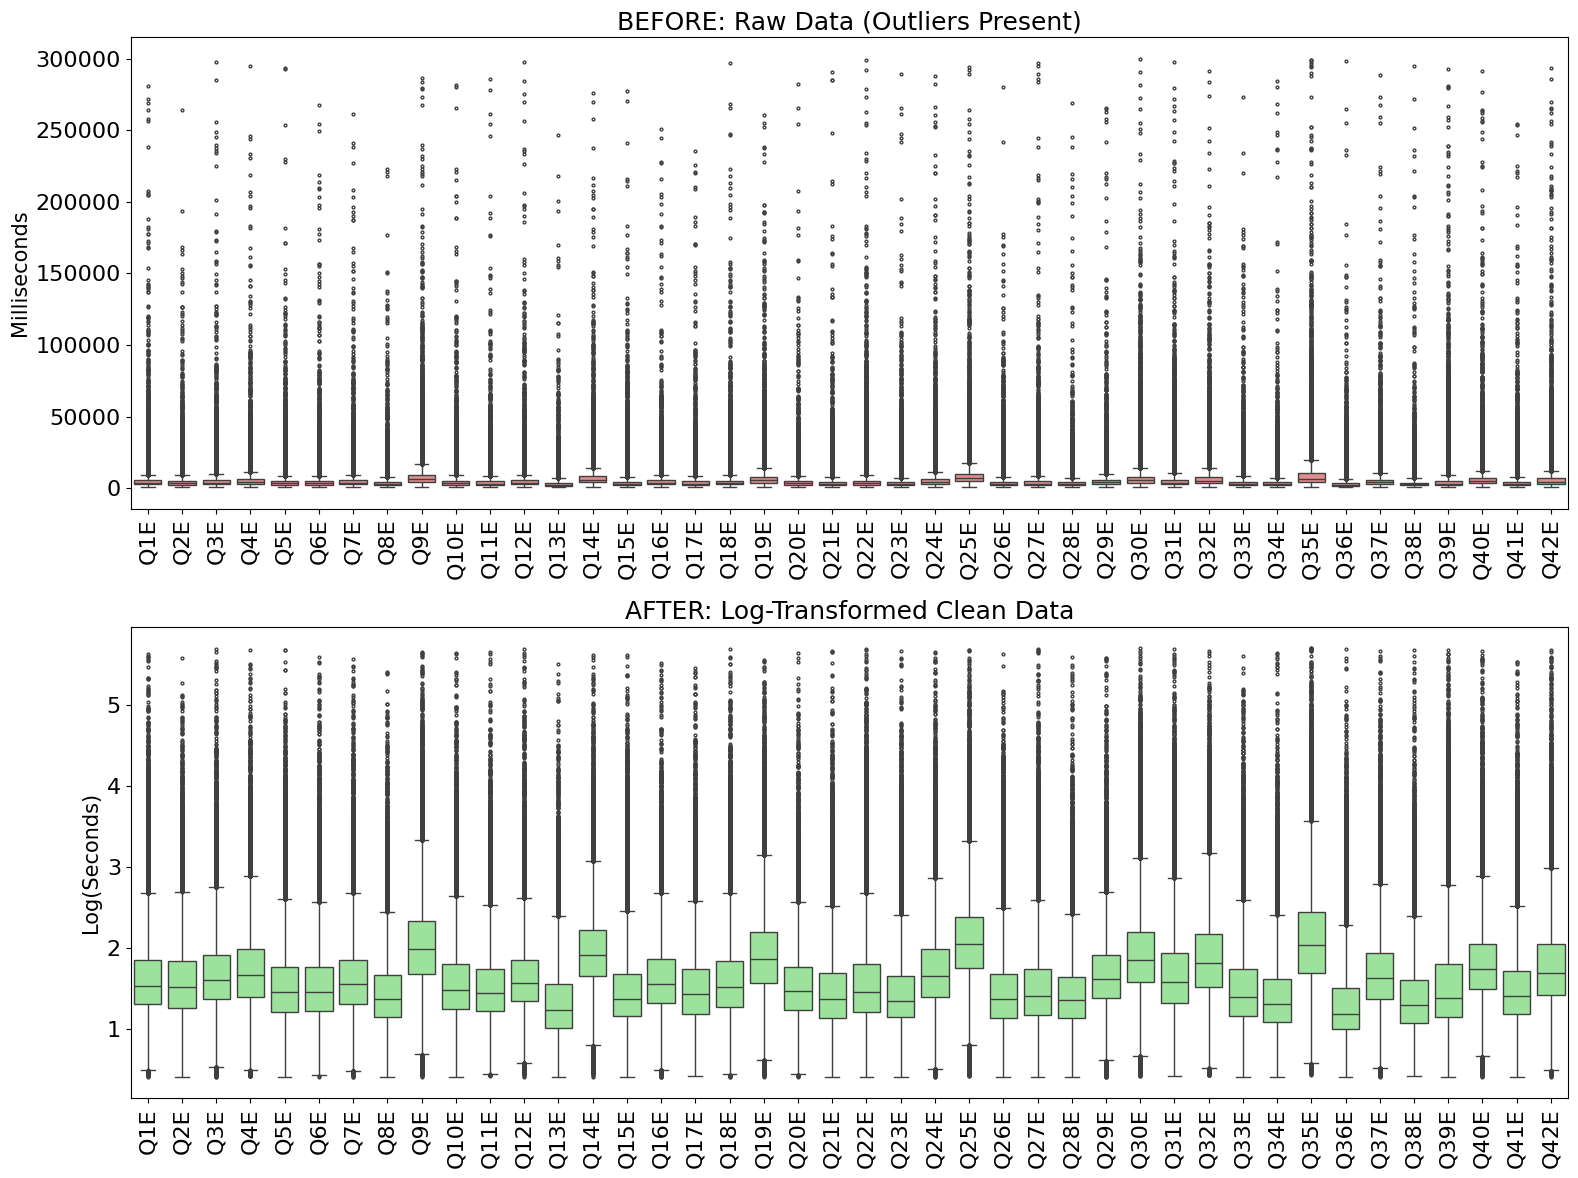

In [ ]:
# Reaction time Transformation

# Log-transform to normalize the skewed distribution
# Divide by 1000 first to convert milliseconds to seconds
for col in e_cols:
    df_clean[col] = np.log1p(df_clean[col] / 1000.0)

# Boxplot before/after comparison
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

sns.boxplot(data=df[e_cols], ax=axes[0], color='lightcoral', fliersize=2)
axes[0].set_title("BEFORE: Raw Data (Outliers Present)", fontsize=18)
axes[0].set_ylabel("Milliseconds", fontsize=15)
axes[0].tick_params(axis='x', rotation=90, labelsize=16)
axes[0].tick_params(axis='y', labelsize=16)

sns.boxplot(data=df_clean[e_cols], ax=axes[1], color='lightgreen', fliersize=2)
axes[1].set_title("AFTER: Log-Transformed Clean Data", fontsize=18)
axes[1].set_ylabel("Log(Seconds)", fontsize=15)
axes[1].tick_params(axis='x', rotation=90, labelsize=16)
axes[1].tick_params(axis='y', labelsize=16)

plt.tight_layout()
plt.show()

## DEMOGRAPHICS EDA


/tmp/ipykernel_14195/526181944.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=gender_label, palette='pastel', order=['Male', 'Female', 'Other'])


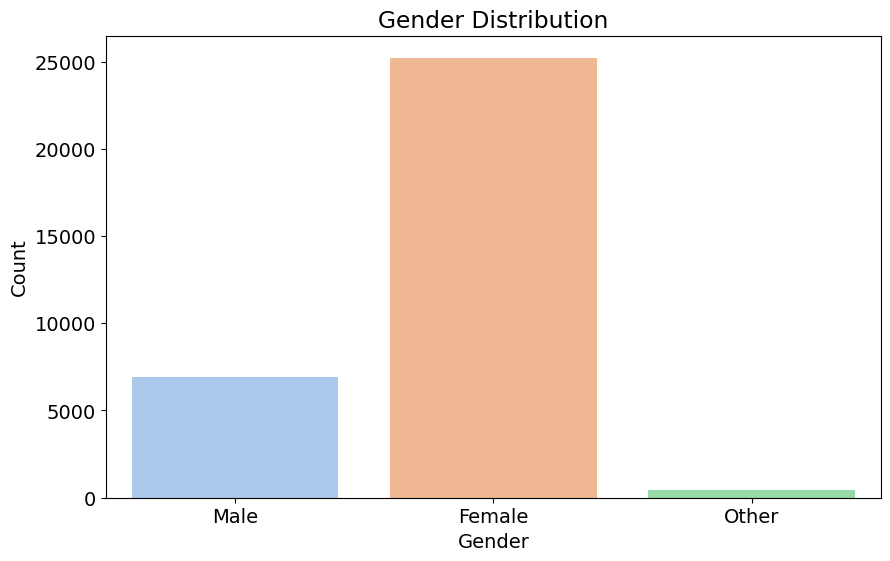

In [ ]:
# Gender
def map_gender(value):
    if value == 1:
        return 'Male'
    elif value == 2:
        return 'Female'
    elif value == 3:
        return 'Other'
    else:
        return 'Missing'

gender_label = df_clean['gender'].apply(map_gender)

plt.figure(figsize=(10, 6))
sns.countplot(x=gender_label, palette='pastel', order=['Male', 'Female', 'Other'])
plt.title("Gender Distribution")
plt.ylabel("Count")
plt.xlabel("Gender")
plt.show()

In [ ]:
gender_proportions = gender_label.value_counts(normalize=True)
print("Gender Proportions:")
print(gender_proportions)

Gender Proportions:
gender
Female     0.772685
Male       0.212671
Other      0.012836
Missing    0.001807
Name: proportion, dtype: float64


/tmp/ipykernel_14195/2576689522.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=education_string, palette='viridis', order=['< High School', 'High School', 'University', 'Graduate'])


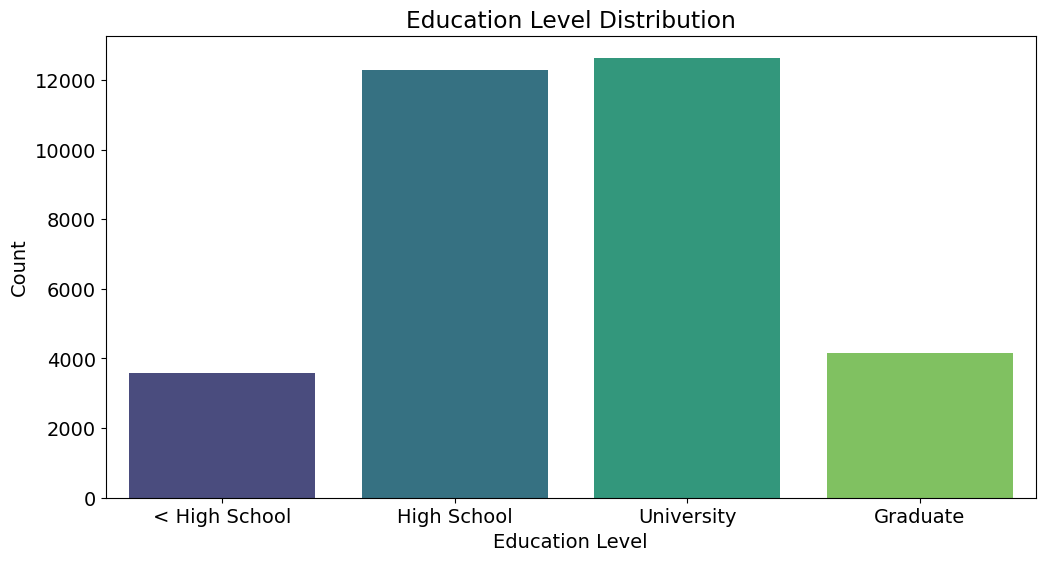

In [ ]:
# Education

df_clean['education'] = df_clean['education'].map({0: 1, 1: 1, 2: 2, 3: 3, 4: 4})

edu_labels = {1: '< High School', 2: 'High School', 3: 'University', 4: 'Graduate'}
education_string = df_clean['education'].map(edu_labels)

plt.figure(figsize=(12, 6))
sns.countplot(x=education_string, palette='viridis', order=['< High School', 'High School', 'University', 'Graduate'])
plt.title("Education Level Distribution")
plt.ylabel("Count")
plt.xlabel("Education Level")
plt.show()

/tmp/ipykernel_14195/2274173225.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=urban_string, palette='mako', order=['Rural', 'Suburban', 'Urban'])


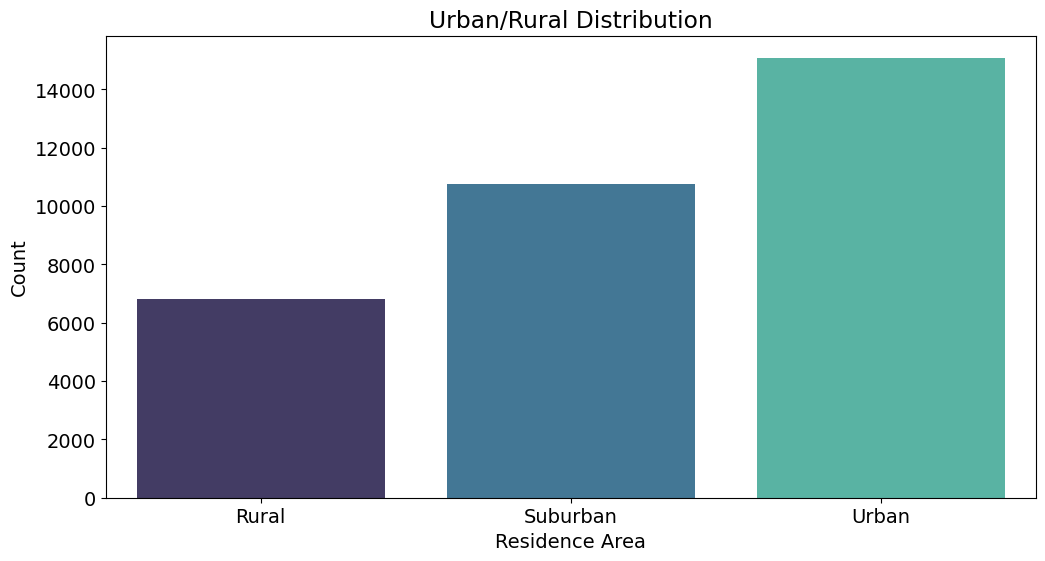

In [ ]:
# Urban

df_clean['urban'] = df_clean['urban'].map({0: 3, 1: 1, 2: 2, 3: 3})

urban_labels = {1: 'Rural', 2: 'Suburban', 3: 'Urban'}
urban_string = df_clean['urban'].map(urban_labels)

plt.figure(figsize=(12, 6))
sns.countplot(x=urban_string, palette='mako', order=['Rural', 'Suburban', 'Urban'])
plt.title("Urban/Rural Distribution")
plt.ylabel("Count")
plt.xlabel("Residence Area")
plt.show()

religion
1      2394
2      2911
3       422
4      2462
5        81
6      1182
7      1760
8       559
9       104
10    19056
11       47
12     1664
Name: count, dtype: int64


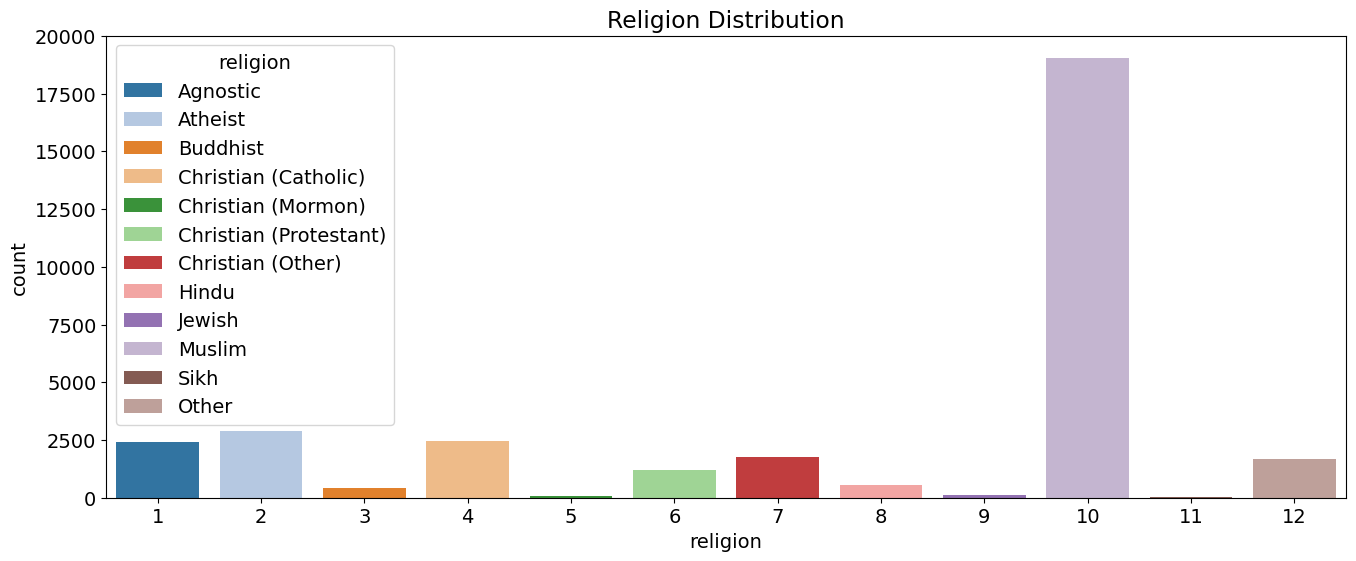

In [ ]:
# Religion
df_clean['religion'] = df_clean['religion'].apply(lambda x: 12 if x == 0 else x)

religion_labels = {
    1: 'Agnostic', 2: 'Atheist', 3: 'Buddhist', 4: 'Christian (Catholic)',
    5: 'Christian (Mormon)', 6: 'Christian (Protestant)', 7: 'Christian (Other)',
    8: 'Hindu', 9: 'Jewish', 10: 'Muslim', 11: 'Sikh', 12: 'Other'
}
religion_string = df_clean['religion'].map(religion_labels)

print(df_clean['religion'].value_counts().sort_index())

plt.figure(figsize=(16, 6))
sns.countplot(x=df_clean['religion'], hue=religion_string, palette='tab20')
plt.title("Religion Distribution")
plt.show()


race
1.0    19832
2.0      267
3.0      451
4.0       12
5.0      154
6.0     7981
7.0     3945
Name: count, dtype: int64


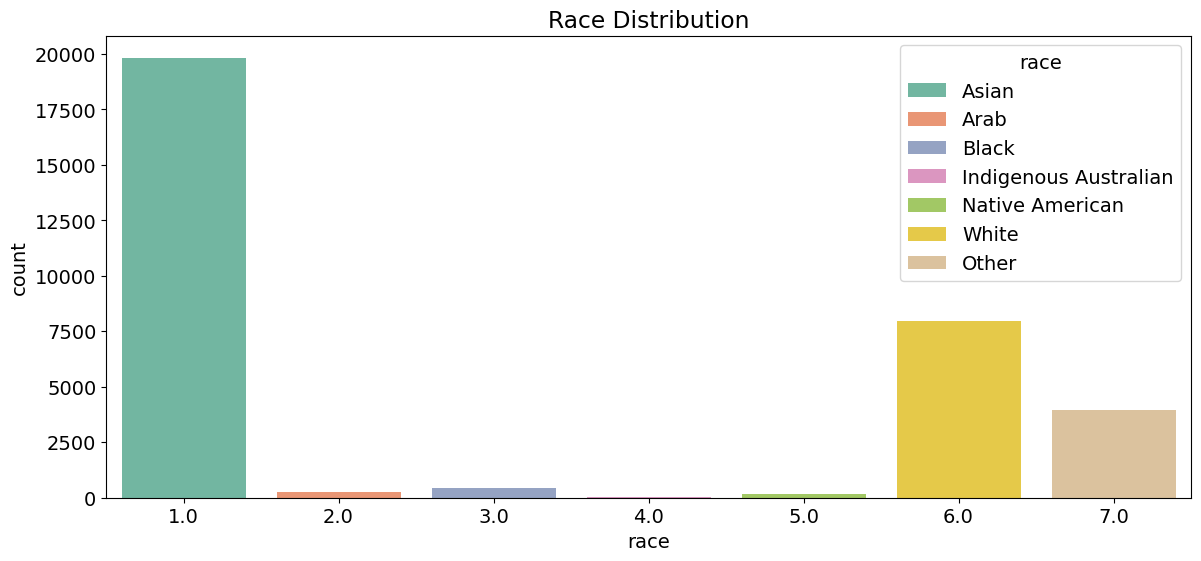

In [ ]:
# Race
df_clean['race'] = df_clean['race'] / 10

race_labels = {
    1: 'Asian', 2: 'Arab', 3: 'Black', 4: 'Indigenous Australian',
    5: 'Native American', 6: 'White', 7: 'Other'
}
race_string = df_clean['race'].map(race_labels)

print(df_clean['race'].value_counts().sort_index())

plt.figure(figsize=(14, 6))
sns.countplot(x=df_clean['race'], hue=race_string, palette='Set2')
plt.title("Race Distribution")
plt.show()



Max family size before filtering: 133
Dataset size after family size filter: 32623


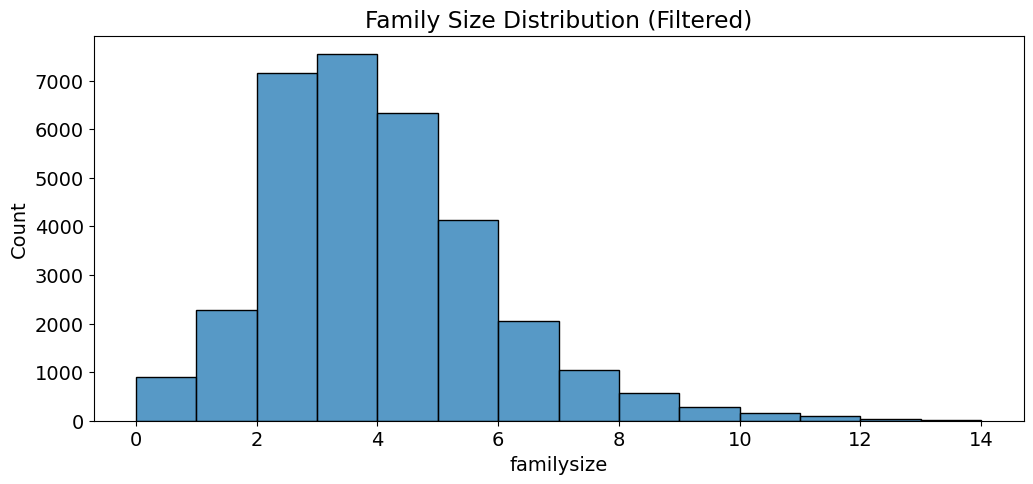

In [ ]:
# Family Size
print(f"Max family size before filtering: {df_clean['familysize'].max()}")
df_clean = df_clean[df_clean['familysize'] <= 13].copy()
print(f"Dataset size after family size filter: {len(df_clean)}")

plt.figure(figsize=(12, 5))
sns.histplot(df_clean['familysize'], bins=range(0, 15), kde=False)
plt.title("Family Size Distribution (Filtered)")
plt.show()


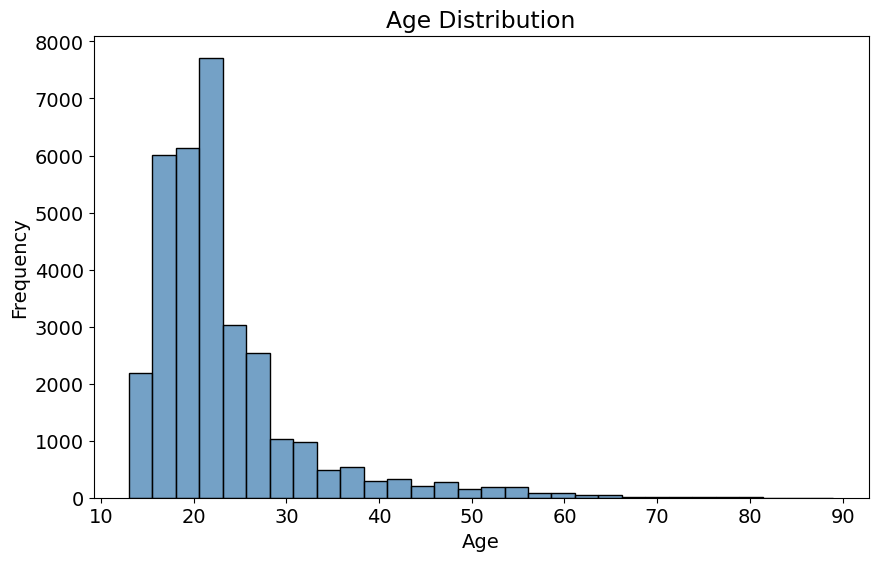

Mean age: 23.31
Median age: 21.0
Age range: 13 to 89


In [ ]:
# Age
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['age'], bins=30, color='steelblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print(f"Mean age: {df_clean['age'].mean():.2f}")
print(f"Median age: {df_clean['age'].median()}")
print(f"Age range: {df_clean['age'].min()} to {df_clean['age'].max()}")

Mean Depression Score by Gender:
gender
Male      20.107493
Female    21.088511
Other     27.026316
Name: Depression_Score, dtype: float64


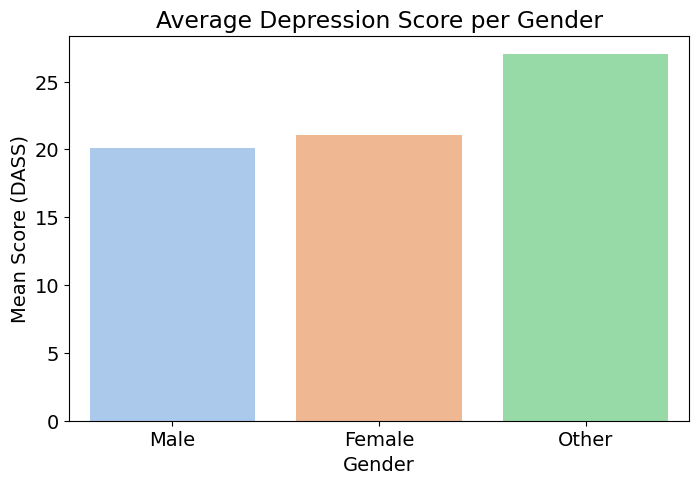

In [ ]:
# EDA: Mean Depression Score by Gender
gender_means = df_clean.groupby(gender_label)['Depression_Score'].mean().reindex(['Male', 'Female', 'Other'])

print("Mean Depression Score by Gender:")
print(gender_means)

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x=gender_means.index, y=gender_means.values, palette='pastel', hue=gender_means.index, legend=False)
plt.title('Average Depression Score per Gender')
plt.ylabel('Mean Score (DASS)')
plt.xlabel('Gender')
plt.show()

Mean Depression Score by Education Level:
education
< High School    24.200893
High School      22.292689
University       19.701140
Graduate         18.051907
Name: Depression_Score, dtype: float64


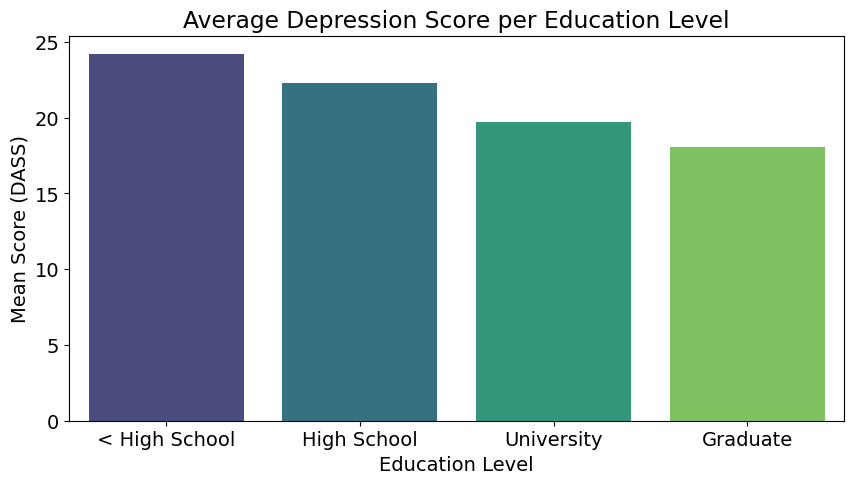

In [ ]:
# EDA: Mean Depression Score by Education
edu_means = df_clean.groupby(education_string)['Depression_Score'].mean().reindex(['< High School', 'High School', 'University', 'Graduate'])

print("Mean Depression Score by Education Level:")
print(edu_means)

# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=edu_means.index, y=edu_means.values, palette='viridis', hue=edu_means.index, legend=False)
plt.title('Average Depression Score per Education Level')
plt.ylabel('Mean Score (DASS)')
plt.xlabel('Education Level')
plt.show()

Mean Depression Score by Residence Area:
urban
Rural       20.633971
Suburban    20.598603
Urban       21.365909
Name: Depression_Score, dtype: float64


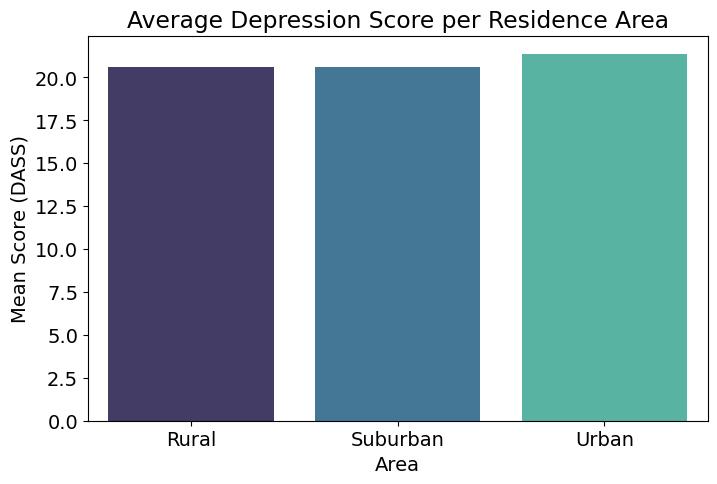

In [ ]:
# EDA: Mean Depression Score by Residence Area
urban_means = df_clean.groupby(urban_string)['Depression_Score'].mean().reindex(['Rural', 'Suburban', 'Urban'])

print("Mean Depression Score by Residence Area:")
print(urban_means)

# Visualization
plt.figure(figsize=(8, 5))
sns.barplot(x=urban_means.index, y=urban_means.values, palette='mako', hue=urban_means.index, legend=False)
plt.title('Average Depression Score per Residence Area')
plt.ylabel('Mean Score (DASS)')
plt.xlabel('Area')
plt.show()

# Analysis

## PNA

In [ ]:
# Select Explicit Answers (Q_A)
qa_cols = [f'Q{i}A' for i in range(1, 43)]
data_pna = df_clean[qa_cols]

# Standardize data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_pna)

In [ ]:
# Graphical Lasso with Cross-Validation
glasso = GraphicalLassoCV(cv=5, max_iter=1000)
glasso.fit(data_scaled)

precision_matrix = glasso.precision_

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


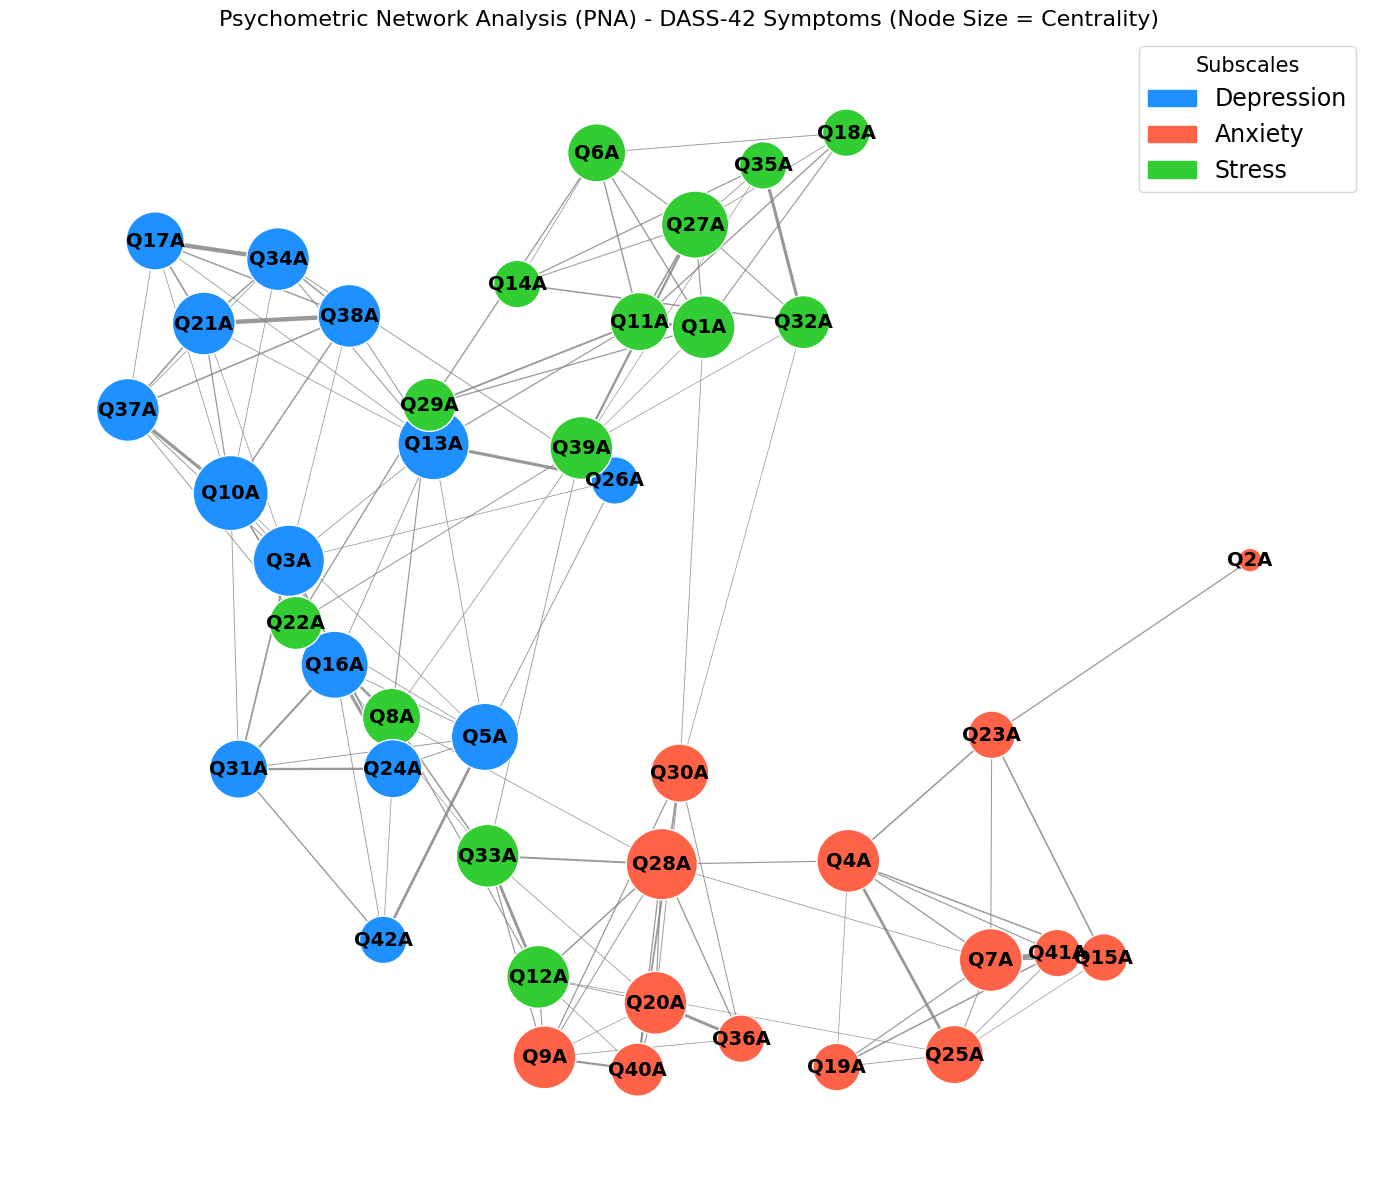

In [ ]:
# Build NetworkX graph
G = nx.Graph()

# DASS-42 subscales
dep_items = ['Q3A', 'Q5A', 'Q10A', 'Q13A', 'Q16A', 'Q17A', 'Q21A', 'Q24A',
             'Q26A', 'Q31A', 'Q34A', 'Q37A', 'Q38A', 'Q42A']
anx_items = ['Q2A', 'Q4A', 'Q7A', 'Q9A', 'Q15A', 'Q19A', 'Q20A', 'Q23A',
             'Q25A', 'Q28A', 'Q30A', 'Q36A', 'Q40A', 'Q41A']
str_items = ['Q1A', 'Q6A', 'Q8A', 'Q11A', 'Q12A', 'Q14A', 'Q18A', 'Q22A',
             'Q27A', 'Q29A', 'Q32A', 'Q33A', 'Q35A', 'Q39A']

color_map = []
for node in qa_cols:
    G.add_node(node)
    if node in dep_items:
        color_map.append('dodgerblue')  # Depression
    elif node in anx_items:
        color_map.append('tomato')      # Anxiety
    else:
        color_map.append('limegreen')   # Stress

# Add edges based on partial correlation threshold
threshold = 0.05
num_nodes = precision_matrix.shape[0]

for i in range(num_nodes):
    for j in range(i + 1, num_nodes):
        partial_corr = -precision_matrix[i, j] / np.sqrt(precision_matrix[i, i] * precision_matrix[j, j])
        if abs(partial_corr) > threshold:
            G.add_edge(qa_cols[i], qa_cols[j], weight=abs(partial_corr))

# Calculate Centrality for Node Sizing
centrality = nx.degree_centrality(G)
# Map centrality to node sizes (scaling for visibility)
node_sizes = [centrality[node] * 12000 for node in G.nodes()]

# Plot network
plt.figure(figsize=(14, 12))
pos = nx.spring_layout(G, k=0.3, seed=42)
weights = [G[u][v]['weight'] * 10 for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=node_sizes, edgecolors='white')
nx.draw_networkx_edges(G, pos, width=weights, alpha=0.8, edge_color='gray')
nx.draw_networkx_labels(G, pos, font_size=14, font_family="sans-serif", font_weight='bold')

blue_patch = mpatches.Patch(color='dodgerblue', label='Depression')
red_patch = mpatches.Patch(color='tomato', label='Anxiety')
green_patch = mpatches.Patch(color='limegreen', label='Stress')

plt.legend(handles=[blue_patch, red_patch, green_patch], loc='upper right', prop={'size': 17}, title="Subscales", title_fontsize=15)

plt.title("Psychometric Network Analysis (PNA) - DASS-42 Symptoms (Node Size = Centrality)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Node centrality

centrality = nx.degree_centrality(G)
most_central_node = max(centrality, key=centrality.get)
print(f"Most central symptom in the network: {most_central_node}")

Most central symptom in the network: Q10A


## XGBoost

In [ ]:
# Bootstrap for confidence interlvas

def bootstrap_metrics(y_true, y_pred, n_iterations=10000, random_state=42):
    r2_scores = []
    mae_scores = []

    # Ensure they are numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    np.random.seed(random_state)
    for i in range(n_iterations):
        # Resample the test set with replacement
        indices = resample(np.arange(len(y_true)), replace=True)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]

        # Calculate metrics for this sample
        r2_scores.append(r2_score(y_true_boot, y_pred_boot))
        mae_scores.append(mean_absolute_error(y_true_boot, y_pred_boot))

    # Calculate 95% CIs (2.5th and 97.5th percentiles)
    r2_ci = (np.percentile(r2_scores, 2.5), np.percentile(r2_scores, 97.5))
    mae_ci = (np.percentile(mae_scores, 2.5), np.percentile(mae_scores, 97.5))

    return r2_ci, mae_ci

In [ ]:
# Ensure nominal columns are integers for clean OHE column names
nominal_cols = ['gender', 'religion', 'race', 'married', 'urban']
for col in nominal_cols:
    df_clean[col] = df_clean[col].astype(int)

# One-Hot Encoding
df_ml = pd.get_dummies(df_clean, columns=nominal_cols, prefix=nominal_cols, drop_first=False)

# Feature lists
qe_cols = [f'Q{i}E' for i in range(1, 43)]
tipi_cols = [f'TIPI{i}' for i in range(1, 11)]

# Find OHE demographic columns
features_ohe = [col for col in df_ml.columns
                     if any(col.startswith(f"{nom}_") for nom in nominal_cols)]
features_ohe += ['age', 'education', 'familysize']

# Define features and target
X = df_ml[qe_cols + tipi_cols + features_ohe]
y = df_ml['Depression_Score']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Feature matrix shape: (32623, 85)
Target vector shape: (32623,)


In [ ]:
# Train / Val / Test Split (70/15/15)

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42)

print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

Train: 22848, Validation: 4881, Test: 4894


### ABLATION STUDY


In [ ]:
def train_evaluate_model(X_tr, X_v, X_te, y_tr, y_v, y_te, feature_cols, model_name):

    print(f"--- Tuning {model_name} ---")

    param_grid = {
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.15],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'min_child_weight': [1, 3]
    }

    xgb_base = xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

    grid_search = GridSearchCV(
        estimator=xgb_base, param_grid=param_grid,
        scoring='neg_mean_absolute_error', cv=3, verbose=0, n_jobs=-1
    )

    # Fit Grid Search on the specific feature subset
    grid_search.fit(X_tr[feature_cols], y_tr)
    best_params = grid_search.best_params_

    # Train final model with early stopping
    model = xgb.XGBRegressor(
        n_estimators=1000, random_state=42, early_stopping_rounds=15, **best_params
    )

    model.fit(
        X_tr[feature_cols], y_tr,
        eval_set=[(X_v[feature_cols], y_v)],
        verbose=False
    )

    preds = model.predict(X_te[feature_cols])
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)

    return model, mae, r2, preds

In [ ]:
# Features for Model A

features_base = features_ohe + tipi_cols
features_base = [c for c in features_base if c in X.columns]

In [ ]:
# Run the Ablation Study

model_a, mae_a, r2_a, preds_a = train_evaluate_model(X_train, X_val, X_test, y_train, y_val, y_test, features_base, "Model A (System 2)")
model_b, mae_b, r2_b, preds_b = train_evaluate_model(X_train, X_val, X_test, y_train, y_val, y_test, qe_cols, "Model B (System 1)")
model_c, mae_c, r2_c, preds_c = train_evaluate_model(X_train, X_val, X_test, y_train, y_val, y_test, list(X.columns), "Model C (Hybrid Full)")

print("\n" + "=" * 60)
print(f"MODEL A (Personality + Demographics):     MAE: {mae_a:.2f} | R2: {r2_a:.4f}")
print(f"MODEL B (Reaction Times Only):            MAE: {mae_b:.2f} | R2: {r2_b:.4f}")
print(f"MODEL C (Hybrid - Full Model):            MAE: {mae_c:.2f} | R2: {r2_c:.4f}")
print("=" * 60)

improvement = (r2_c - r2_a) / r2_a * 100
print(f"\nAdding reaction times improved predictive accuracy (R2) by {improvement:.1f}%")

--- Tuning Model A (System 2) ---
--- Tuning Model B (System 1) ---
--- Tuning Model C (Hybrid Full) ---

MODEL A (Personality + Demographics):     MAE: 7.78 | R2: 0.3867
MODEL B (Reaction Times Only):            MAE: 8.88 | R2: 0.2238
MODEL C (Hybrid - Full Model):            MAE: 7.06 | R2: 0.4734

Adding reaction times improved predictive accuracy (R2) by 22.4%


In [ ]:
# Run bootstrapping for all three models
r2_ci_a, mae_ci_a = bootstrap_metrics(y_test, preds_a)
r2_ci_b, mae_ci_b = bootstrap_metrics(y_test, preds_b)
r2_ci_c, mae_ci_c = bootstrap_metrics(y_test, preds_c)

print("\n" + "=" * 70)
print("95% CONFIDENCE INTERVALS (10000 Bootstrap Samples)")
print("=" * 70)
print(f"MODEL A (System 2): R2: {r2_a:.4f} (95% CI: {r2_ci_a[0]:.4f} - {r2_ci_a[1]:.4f}) | MAE: {mae_a:.2f} (95% CI: {mae_ci_a[0]:.2f} - {mae_ci_a[1]:.2f})")
print(f"MODEL B (System 1): R2: {r2_b:.4f} (95% CI: {r2_ci_b[0]:.4f} - {r2_ci_b[1]:.4f}) | MAE: {mae_b:.2f} (95% CI: {mae_ci_b[0]:.2f} - {mae_ci_b[1]:.2f})")
print(f"MODEL C (Hybrid):   R2: {r2_c:.4f} (95% CI: {r2_ci_c[0]:.4f} - {r2_ci_c[1]:.4f}) | MAE: {mae_c:.2f} (95% CI: {mae_ci_c[0]:.2f} - {mae_ci_c[1]:.2f})")
print("=" * 70)



95% CONFIDENCE INTERVALS (10000 Bootstrap Samples)
MODEL A (System 2): R2: 0.3867 (95% CI: 0.3633 - 0.4087) | MAE: 7.78 (95% CI: 7.63 - 7.95)
MODEL B (System 1): R2: 0.2238 (95% CI: 0.2017 - 0.2460) | MAE: 8.88 (95% CI: 8.71 - 9.05)
MODEL C (Hybrid):   R2: 0.4734 (95% CI: 0.4505 - 0.4942) | MAE: 7.06 (95% CI: 6.91 - 7.21)


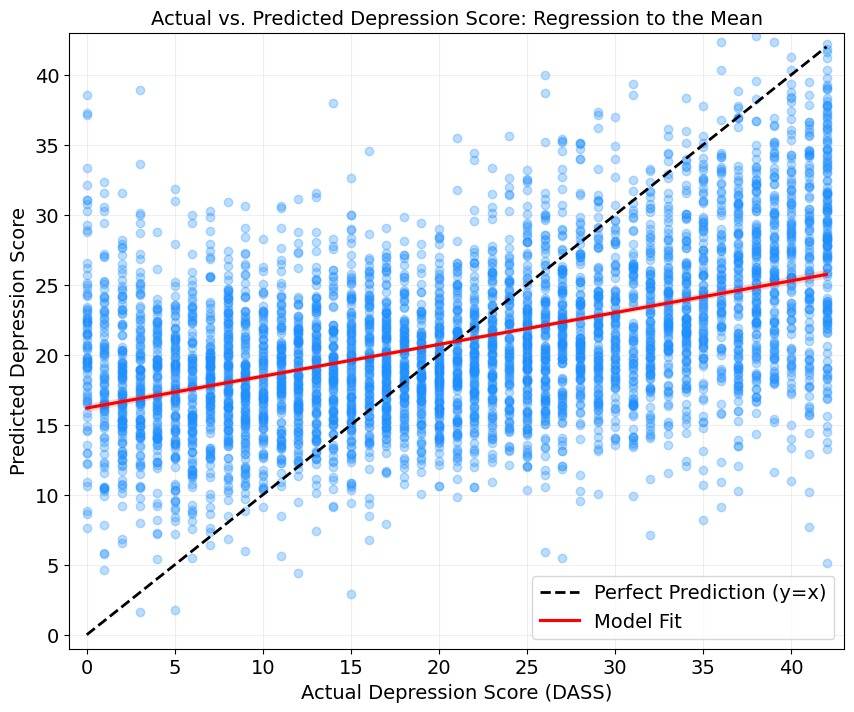

In [ ]:
# Final scatter plot

plt.figure(figsize=(10, 8))

# Reference line for perfect prediction (y=x)
plt.plot([0, 42], [0, 42], color='black', lw=2, ls='--', label='Perfect Prediction (y=x)')

# Regression plot
sns.regplot(x=y_test, y=preds_b,
            scatter_kws={'alpha': 0.3, 'color': 'dodgerblue'},
            line_kws={'color': 'red', 'ls': '-', 'label': 'Model Fit'})

plt.title('Actual vs. Predicted Depression Score: Regression to the Mean', fontsize=14)
plt.xlabel('Actual Depression Score (DASS)')
plt.ylabel('Predicted Depression Score')
plt.xlim(-1, 43)
plt.ylim(-1, 43)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [ ]:
save_path = '/content/drive/MyDrive/models_output/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Save models
models = {'model_a': model_a, 'model_b': model_b, 'model_c': model_c}

for name, model in models.items():
    file_path = os.path.join(save_path, f'{name}.pkl')
    with open(file_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Saved {name} to {file_path}")


Saved model_a to /content/drive/MyDrive/models_output/model_a.pkl
Saved model_b to /content/drive/MyDrive/models_output/model_b.pkl
Saved model_c to /content/drive/MyDrive/models_output/model_c.pkl


In [ ]:
# Load models
with open(os.path.join(save_path, 'model_a.pkl'), 'rb') as f:
    loaded_model_a = pickle.load(f)

with open(os.path.join(save_path, 'model_b.pkl'), 'rb') as f:
    loaded_model_b = pickle.load(f)

with open(os.path.join(save_path, 'model_c.pkl'), 'rb') as f:
    loaded_model_c = pickle.load(f)

# Shap

In [ ]:
explainer = shap.TreeExplainer(model_c)
shap_values = explainer(X_test)

/tmp/ipykernel_14195/3245885171.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, max_display=15, show=False)


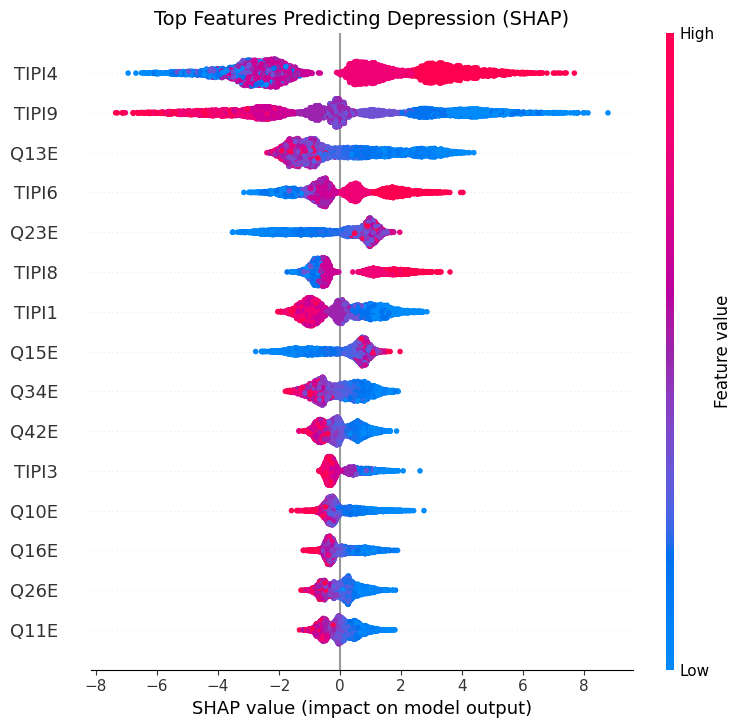

In [ ]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title("Top Features Predicting Depression (SHAP)", fontsize=14)
plt.tight_layout()
plt.show()

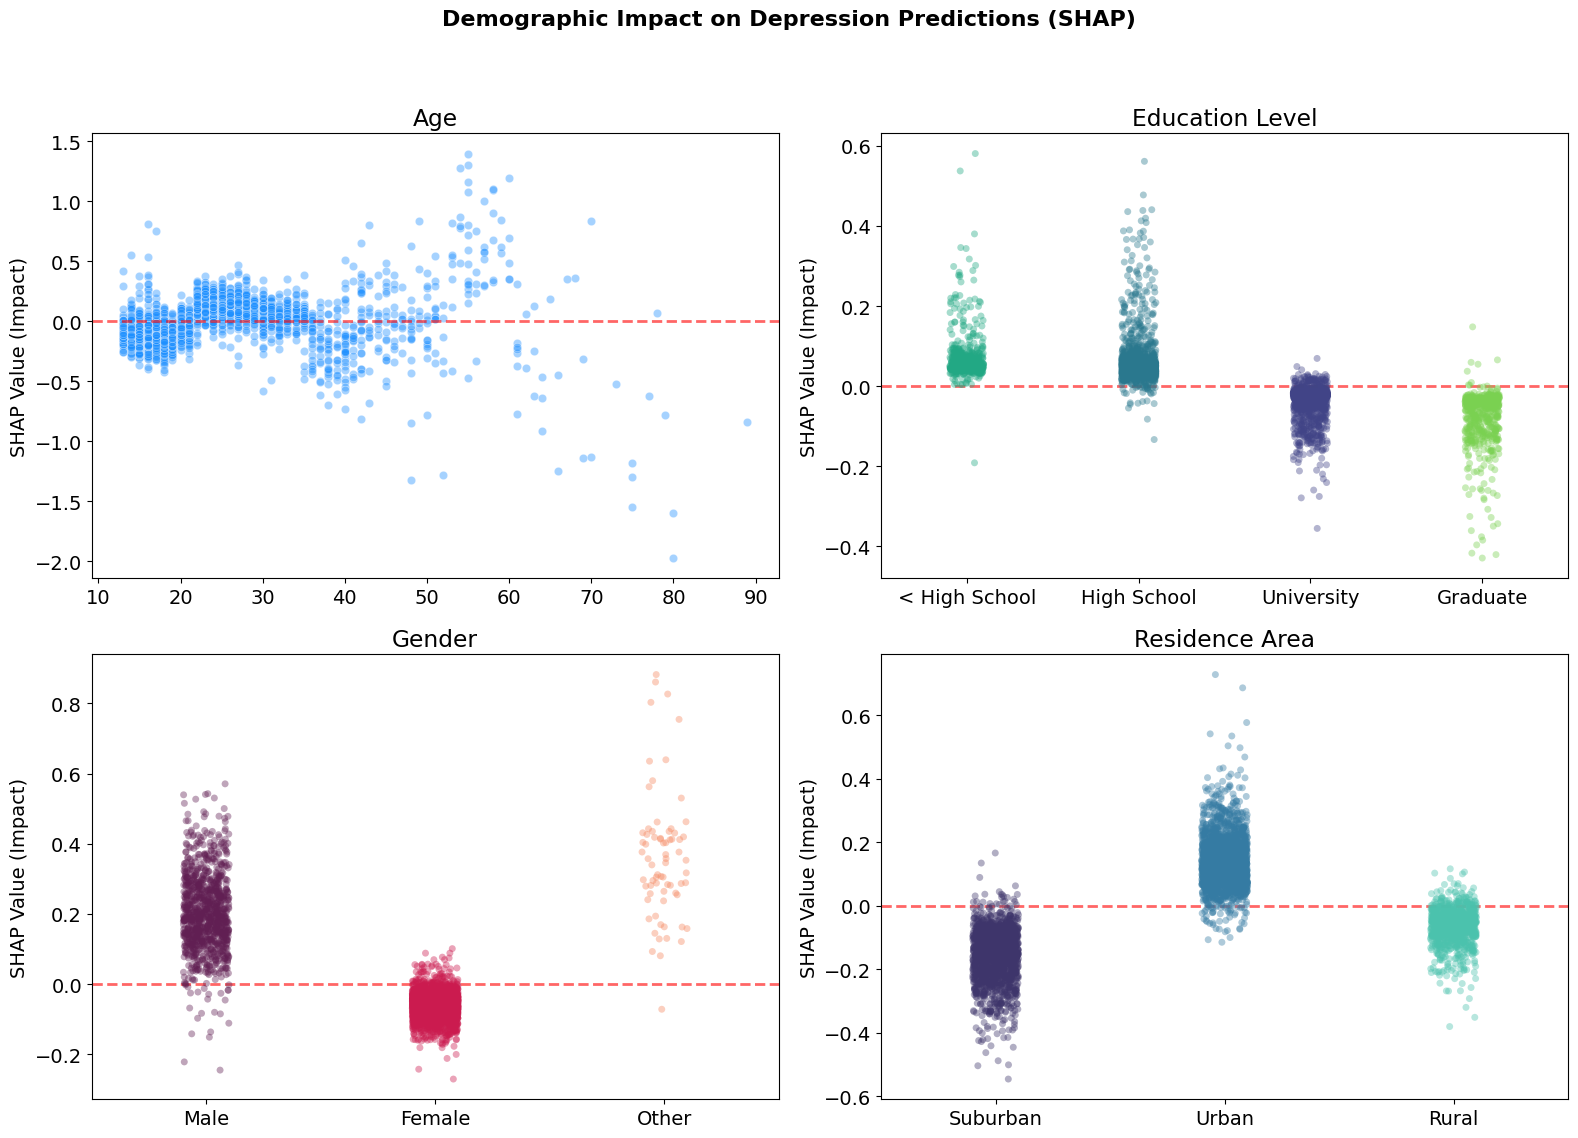

In [ ]:
# Detailed Demographic SHAP

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Demographic Impact on Depression Predictions (SHAP)', fontsize=16, fontweight='bold')
axes = axes.flatten()

# Age
idx_age = list(X_test.columns).index('age')
sns.scatterplot(x=X_test['age'], y=shap_values.values[:, idx_age], alpha=0.4, color='dodgerblue', ax=axes[0])
axes[0].set_title('Age')
axes[0].set_ylabel('SHAP Value (Impact)')

# Education
idx_edu = list(X_test.columns).index('education')
edu_vals = X_test['education'].map(edu_labels)
sns.stripplot(x=edu_vals, y=shap_values.values[:, idx_edu], hue=edu_vals, palette='viridis', ax=axes[1],
              order=['< High School', 'High School', 'University', 'Graduate'], alpha=0.4, jitter=True, legend=False)
axes[1].set_title('Education Level')
axes[1].set_ylabel('SHAP Value (Impact)')

# Gender
gender_cols = [c for c in X_test.columns if c.startswith('gender_')]
gender_shap = pd.DataFrame({
    'Gender': [('Male' if row['gender_1'] == 1 else 'Female' if row['gender_2'] == 1 else 'Other') for _, row in X_test.iterrows()],
    'SHAP': [sum(shap_values.values[i, list(X_test.columns).index(c)] for c in gender_cols) for i in range(len(X_test))]
})
sns.stripplot(x='Gender', y='SHAP', data=gender_shap, hue='Gender', palette='rocket', ax=axes[2], alpha=0.4, jitter=True, legend=False)
axes[2].set_title('Gender')
axes[2].set_ylabel('SHAP Value (Impact)')

# Urban
urban_cols = [c for c in X_test.columns if c.startswith('urban_')]
urban_shap = pd.DataFrame({
    'Area': [('Rural' if row['urban_1'] == 1 else 'Suburban' if row['urban_2'] == 1 else 'Urban') for _, row in X_test.iterrows()],
    'SHAP': [sum(shap_values.values[i, list(X_test.columns).index(c)] for c in urban_cols) for i in range(len(X_test))]
})
sns.stripplot(x='Area', y='SHAP', data=urban_shap, hue='Area', palette='mako', ax=axes[3], alpha=0.4, jitter=True, legend=False)
axes[3].set_title('Residence Area')
axes[3].set_ylabel('SHAP Value (Impact)')

for ax in axes:
    ax.axhline(0, color='red', linestyle='--', alpha=0.6, lw=2)
    ax.set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Shap dependence plot

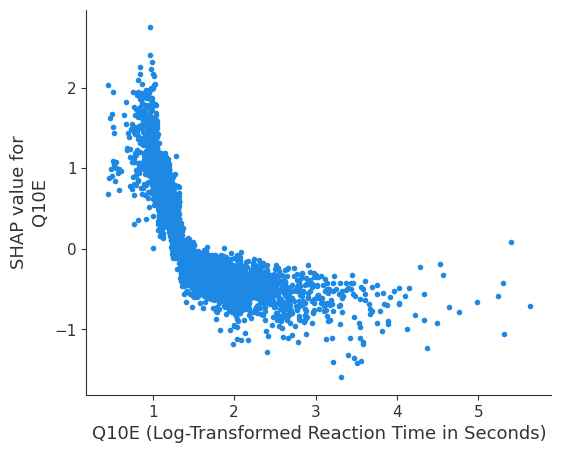

In [ ]:
shap.dependence_plot("Q10E",
                     shap_values.values,
                     X_test,
                     interaction_index=None,
                     show=False
)
plt.xlabel("Q10E (Log-Transformed Reaction Time in Seconds)")
plt.show()